In [1]:
# --- repo-root prelude (added 2026-08-02 with the folder reorganisation) ---
# This notebook lives in a subfolder but every path below is relative to the REPO ROOT,
# and `import features` needs the root on sys.path. Walk up until we find paths.py, so it
# works whether Jupyter was started here or at the root. Idempotent.
import os, sys
while not os.path.exists('paths.py') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
import paths  # noqa: F401  - also puts pipeline/ + models/ on sys.path
# --- end prelude ---


# Predicting election winners with XGBoost

Loads the long poll dataset (`polls_long_with_results.csv` from `build_dataset.ipynb`), engineers features (polls **plus** fundamentals: partisan lean, incumbency, prior margin), collapses to **one row per candidate per race**, and trains a gradient-boosted classifier for `won`.

**Honest framing up front:** for *calling the winner*, the polling leader is already right ~88–95% of the time, so a model barely beats that on accuracy. The model's value is **calibrated win probabilities** (useful for close races, ratings, betting markets) — judged by AUC / log-loss / Brier, not just accuracy.

**Validation:** split by year — train on 2018/2020/2022, test on 2024 (~133 races, each House district counted separately) — so we never leak the future.

In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (accuracy_score, roc_auc_score, log_loss,
                             brier_score_loss, confusion_matrix,
                             average_precision_score, roc_curve)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
print('xgboost', xgb.__version__)

xgboost 3.2.0


## 1. Load & filter

Keep only polls that matched a result (`has_result == 1`) and general-election cycles (even years 2018–2024).

In [3]:
from cycles import CYCLES, TUNE_CYCLES, EVAL_CYCLES, natl_env
import features as F

d = pd.read_csv('polls_long_with_results.csv', low_memory=False)
# DEAD MATCHUPS. A survey asks several head-to-heads (question_id) and each number is
# only meaningful against the opponent named in it. Filtering on has_result==1 alone
# keeps the real nominee's row from a question whose OPPONENT never made the ballot -
# a number measured against someone who never ran. 7.9% of general questions (666 of
# 8,394) are mixed like that. Drop the whole question, matching what predict.py's
# drop_primary_losers does at serve time (added 2026-08-06).
_gen = d[d['stage'] == 'general']
_q = _gen.groupby(['race_id', 'question_id'])['has_result'].agg(['sum', 'size'])
_dead = set(_q[(_q['sum'] > 0) & (_q['sum'] < _q['size'])].index)
_key = list(zip(d['race_id'], d['question_id']))
_drop = pd.Series([k in _dead for k in _key], index=d.index) & (d['stage'] == 'general')
print(f'dead-matchup rows dropped from training: {int(_drop.sum())} '
      f'({len(_dead)} questions)')
d = d[~_drop]
d = d[d['has_result'] == 1].copy()
d = F.prepare_polls(d)                     # dates, days_to_elec, district normalization
d = d[d['year'].isin(CYCLES)].copy()
# rebuild race_id from the normalized district (guards the '1.0' float round-trip bug)
d['race_id'] = (d['year'].astype(str) + '_' + d['state'] + '_' + d['office']
                + d['district'].radd('-').where(d['district'] != '', ''))

print('poll rows:', len(d))
print('races:', d['race_id'].nunique())
print('by cycle (races):', d.groupby('year')['race_id'].nunique().to_dict())


dead-matchup rows dropped from training: 1735 (745 questions)
poll rows: 31872
races: 1985
by cycle (races): {1998: 89, 2000: 72, 2002: 120, 2004: 89, 2006: 168, 2008: 133, 2010: 232, 2012: 139, 2014: 148, 2016: 109, 2018: 229, 2020: 150, 2022: 174, 2024: 133}


## 1b. External features: incumbency, prior margin, national environment

All leak-free, all from committed static files (no network, no 538-only data):

- **Incumbency** — `incumbent_party` per race from the frozen `races.csv`; unknown incumbency is **NaN** (missing), never a silent 0.
- **Prior same-office margin** — the most recent **previous** election's two-party margin for that exact seat, from the frozen results files.
- **National environment** (`natl_env_cand`) — generic-ballot DEM−REP margin over the last 30 days before each election: computed from the committed daily history for 1998–2016, frozen values for 2018–2024 (see `cycles.py`).

The 538 partisan-lean file was **removed entirely** (single 2022 vintage = look-ahead leakage for other cycles; `prior_margin_cand` carries the same structural signal cleanly). All signed toward the candidate's own party.

In [4]:
# Fundamentals (incumbency, prior same-seat margin) + national environment.
# All from committed static files via features.py / cycles.py — NO network, NO 538-only
# columns (the partisan-lean file is gone from the pipeline entirely; prior_margin_cand
# carries the structural-lean signal leak-free).
FUNDS = F.load_fundamentals()
NATL_ENV = natl_env()
FEC = F.load_fec(extended=True)
BIAS = F.compute_bias_priors(d)
# primary-strength block, production 2026-08-07 (user call).
PRIMRES = F.load_primary_results()   # prior-cycles poll-bias by state (leak-free)     # fundraising: receipts + indiv/PAC/party/self composition (Sen+House)

print('incumbent records:', len(FUNDS['inc_map']),
      '| prior-margin races:', len(FUNDS['margin_map']))
print('natl_env (DEM-REP, last 30d before election):')
print({k: NATL_ENV.get(k) for k in CYCLES})

incumbent records: 12188 | prior-margin races: 8695
natl_env (DEM-REP, last 30d before election):
{1998: 1.3, 2000: 1.95, 2002: 1.72, 2004: 2.89, 2006: 12.66, 2008: 9.1, 2010: -3.72, 2012: 1.36, 2014: -0.49, 2016: 3.54, 2018: 7.8, 2020: 7.5, 2022: 0.7, 2024: 0.1}


## 1c. Macro / political-climate features

National per-cycle conditions: **presidential approval, inflation (YoY), real GDP growth, unemployment, and gas prices.** For each metric we compute campaign-year **trajectory stats** — election-eve level, mean, max, std (spread), and trend — not just a single snapshot (volatile inflation may matter more than its level, etc.).

These are national values (constant within a cycle), so on their own they can't rank candidates *within* a race. We add **`is_president_party`** (1 if the candidate's party holds the White House) as the interaction key — XGBoost can then learn effects like "low approval + in-party → headwind" without us hard-coding the sign.

Data: economic series from **FRED** (live download); approval + an election-eve fallback table are in `macro_features.py` so the cell runs even if FRED is unreachable. **With only 4 cycles these features are weak and must be used with heavy regularization** — see the re-tuned hyperparameters in section 10.

In [5]:
from macro_features import build_macro, PRES_PARTY

# Reads the static monthly macro CSV (data/macro_monthly.csv) produced once by fetch_macro.py.
# No network here — the data is fixed historical record. If the CSV is missing, this raises a
# clear error telling you to run `python fetch_macro.py` first.
macro = build_macro()
MACRO_FEATS = sorted({k for cyc in macro for k in macro[cyc]})
print('president party by cycle:', PRES_PARTY)
print(f'macro features per cycle: {len(MACRO_FEATS)}')
print('sample (2022):', {k: round(v, 2) for k, v in list(macro[2022].items())[:6]}, '...')

president party by cycle: {1998: 'DEM', 2000: 'DEM', 2002: 'REP', 2004: 'REP', 2006: 'REP', 2008: 'REP', 2010: 'DEM', 2012: 'DEM', 2014: 'DEM', 2016: 'DEM', 2018: 'REP', 2020: 'REP', 2022: 'DEM', 2024: 'DEM', 2026: 'REP'}
macro features per cycle: 144
sample (2022): {'approval_eve': 42.0, 'approval_mean': 44.98, 'approval_max': 57.0, 'approval_min': 34.0, 'approval_std': 6.54, 'approval_trend': -0.48} ...


## 2. Raw polls, no weighting

**All poll aggregates are plain averages.** The old pipeline weighted polls by recency × √sample × 538 pollster grade — but 538's grades don't exist for future polls, so weighted features would be computed on a different scale at predict time than at train time (train/serve skew). Recency information still reaches the model through *explicit* features: `poll_last`, `poll_last30`, `min_days`, `poll_momentum`, `gap_x_recency`.

In [6]:
# Poll WEIGHTING was removed (2026-07-05): every aggregate is a plain average of raw polls.
# The old weight mixed recency x sqrt(sample) x 538 pollster grade — the grade doesn't exist
# for future polls, so weighted features would be computed differently at train vs predict
# time (train/serve skew). Recency still enters the model through explicit features
# (poll_last30, min_days, gap_x_recency, poll_momentum) rather than through hidden weights.
# The lead-dynamics helpers (count_lead_changes, margin_dynamics) live in features.py now.
print('raw-poll plain averages; aggregation helpers in features.py')

raw-poll plain averages; aggregation helpers in features.py


## 3. Collapse to one row per candidate per race

Aggregate every poll for a candidate into a feature vector. Then add **race-relative** features (lead over best opponent, share of the polled field) — these matter more than raw % because elections are relative.

In [7]:
# Build the candidate table once (BASE), then derive leak-free per-fold copies: the ONLY
# fold-dependent quantity is poll_adj (pollster house effect must come from train cycles
# only), so each fold just swaps that column instead of rebuilding everything.
# bio_office_level SHIPPED 2026-07-29: after office_level coverage reached 100% (leak-free,
# fact-checked), the re-ablation flipped positive on BOTH models (win race-acc +0.0043, margin
# MAE -0.071) - reversing the earlier "don't ship" verdict which was a coverage artifact. Pass
# candidate_bios here AND at serve time (predict.py) so bio_office_level is populated in both.
BIOS = F.load_candidate_bios()
BASE = F.build_candidate_table(d, macro, NATL_ENV, FUNDS, house_train_years=CYCLES, fec=FEC,
                               bias_priors=BIAS, candidate_bios=BIOS,
                               primary_results=PRIMRES)

def fold_table(test_year):
    house = F.compute_house_effect(d, [y for y in CYCLES if y != test_year])
    adj = F.candidate_poll_adj(d, house).rename('poll_adj').reset_index()
    return BASE.drop(columns='poll_adj').merge(adj, on=['race_id', 'cand_key'], how='left')

FOLDS = {ty: fold_table(ty) for ty in CYCLES}
cand = FOLDS[2024]           # the single-split walkthrough below tests on 2024

# sanity checks
_h = cand[cand['office'] == 'House']
print('House prior_margin coverage:', round(_h['prior_margin_cand'].notna().mean(), 3),
      '| House is_incumbent rate:', round(_h['is_incumbent'].mean(), 3))
assert _h['prior_margin_cand'].notna().mean() > 0.5, 'House district keys are broken again!'
assert cand['won'].notna().all(), 'training rows must all have labels'
print('bio_office_level coverage:', round(cand['bio_office_level'].notna().mean(), 3))

print('candidate-races:', len(cand), '| win rate:', round(cand['won'].mean(), 3))
print('cycles present:', sorted(cand['year'].unique()))
print('macro columns present:', sum(c in cand.columns for c in MACRO_FEATS), 'of', len(MACRO_FEATS))
cand[['year','state','office','candidate','party','poll_avg','poll_lead',
      'prior_margin_cand','is_incumbent','won']].head(8)

House prior_margin coverage: 0.68 | House is_incumbent rate: 0.472
bio_office_level coverage: 0.995
candidate-races: 4462 | win rate: 0.444
cycles present: [np.int64(1998), np.int64(2000), np.int64(2002), np.int64(2004), np.int64(2006), np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022), np.int64(2024)]
macro columns present: 144 of 144


,year,state,office,candidate,party,poll_avg,poll_lead,prior_margin_cand,is_incumbent,won
0,1998,AL,Governor,"Forrest H. 'Fob' James, Jr.",REP,39.600000,-11.000000,NaN,1.0,0
1,1998,AL,Governor,Don Siegelman,DEM,50.600000,11.000000,NaN,0.0,1
2,1998,AL,Senate,Richard C. Shelby,REP,62.000000,35.000000,6.988495,1.0,1
3,1998,AL,Senate,Clayton Suddith,DEM,27.000000,-35.000000,-6.988495,0.0,0
4,1998,AR,Governor,Bill Bristow,DEM,31.333333,-28.333333,NaN,0.0,0
5,1998,AR,Governor,Mike Huckabee,REP,59.666667,28.333333,NaN,1.0,1
6,1998,AR,House,Victor F. Snyder,DEM,54.000000,19.000000,NaN,1.0,1
7,1998,AR,House,Phil Wyrick,REP,35.000000,-19.000000,NaN,0.0,0


## 4. Train / test split by year

Train on 2018/2020/2022, test on 2024. **Never** include `vote_pct` / `race_winning_pct` — those are outcomes.

In [8]:
FEATURES = F.feature_list(MACRO_FEATS, fund=True, candidate_bios=True,
                           primary_results=True,
                           exclude=F.WIN_EXCLUDE)
# every feature is available for FUTURE races (no 538 grades/pollscore/lean — see features.py).
# candidate_bios=True adds bio_office_level (shipped 2026-07-29 - see the BASE-build cell).

train = cand[cand['year'] != 2024]
test  = cand[cand['year'] == 2024]
X_train, y_train = train[FEATURES], train['won'].astype(int)
X_test,  y_test  = test[FEATURES],  test['won'].astype(int)
print('train:', X_train.shape, '| test:', X_test.shape, '| total features:', len(FEATURES))
print('train win rate:', round(y_train.mean(), 3), '| test win rate:', round(y_test.mean(), 3))

train: (4124, 207) | test: (338, 207) | total features: 207
train win rate: 0.448 | test win rate: 0.393


In [9]:
# Leave-one-cycle-out scorer over an arbitrary set of test cycles.
# FOLDS[ty] already carries the leak-free poll_adj for test cycle ty (built above).
def cv_auc_brier(Fts, params, test_cycles):
    aucs, briers = [], []
    for ty in test_cycles:
        c = FOLDS[ty]
        tr = c[c['year'] != ty]; te = c[c['year'] == ty]
        m = xgb.XGBClassifier(eval_metric='logloss', random_state=42, **params)
        m.fit(tr[Fts], tr['won'].astype(int))
        p = m.predict_proba(te[Fts])[:, 1]
        aucs.append(roc_auc_score(te['won'].astype(int), p))
        briers.append(brier_score_loss(te['won'].astype(int), p))
    return float(np.mean(aucs)), float(np.mean(briers))

print('folds ready:', list(FOLDS))

folds ready: [1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]


## 5. Tune hyperparameters — nested scheme (tune old, evaluate modern)

The grid is scored by leave-one-cycle-out CV **over the 1998–2016 cycles only**. The modern cycles (2018–2024) are never touched by the tuner, so section 10's evaluation is a genuine out-of-selection estimate (the old setup tuned and reported on the same folds, which inflates the reported numbers — CONCERNS.md #4).

**Workflow rule still applies:** the search runs live on every full run; never hardcode hyperparameters tuned for a different feature set.

In [10]:
import itertools, random

# NESTED tuning scheme (honest headline numbers — see CONCERNS.md #4):
# hyperparameters are selected by leave-one-cycle-out CV over the OLD cycles only
# (1998-2016). The modern cycles (2018-2024) are never seen by the tuner, so the
# evaluation in section 10 is a true out-of-selection estimate.
GRID = dict(max_depth=[1, 2], learning_rate=[0.02, 0.03, 0.05],
            n_estimators=[150, 300], min_child_weight=[8, 15, 30],
            subsample=[0.6, 0.8, 1.0], colsample_bytree=[0.4, 0.6, 1.0],
            reg_lambda=[1, 5, 20], reg_alpha=[0, 1])
keys = list(GRID)
combos = list(itertools.product(*[GRID[k] for k in keys]))
random.seed(0); random.shuffle(combos); combos = combos[:150]   # sample 150 configs

best = None
for combo in combos:
    p = dict(zip(keys, combo))
    a, b = cv_auc_brier(FEATURES, p, TUNE_CYCLES)
    if best is None or a > best[0]:
        best = (a, b, p)

XGB_PARAMS = dict(best[2], eval_metric='logloss', random_state=42)
print(f'best TUNE-cycle CV (1998-2016)  AUC {best[0]:.4f}  Brier {best[1]:.4f}')
print('  (selection score — the honest numbers are the 2018-2024 eval in section 10)')
print('XGB_PARAMS =', {k: v for k, v in XGB_PARAMS.items() if k not in ('eval_metric', 'random_state')})

# fit the single-split walkthrough model (train = all cycles but 2024, test = 2024).
# 2024 was not part of hyperparameter selection, so this split is honest too.
model = xgb.XGBClassifier(**XGB_PARAMS)
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba > 0.5).astype(int)

best TUNE-cycle CV (1998-2016)  AUC 0.9520  Brier 0.0880
  (selection score — the honest numbers are the 2018-2024 eval in section 10)
XGB_PARAMS = {'max_depth': 2, 'learning_rate': 0.03, 'n_estimators': 300, 'min_child_weight': 8, 'subsample': 0.6, 'colsample_bytree': 1.0, 'reg_lambda': 5, 'reg_alpha': 0}


## 6. Evaluate (candidate level)

In [11]:
print('=== candidate-level (test = 2024) ===')
print('AUC      ', round(roc_auc_score(y_test, proba), 3))
print('LogLoss  ', round(log_loss(y_test, proba), 3))
print('Brier    ', round(brier_score_loss(y_test, proba), 3), ' (lower = better calibrated)')
print('Accuracy ', round(accuracy_score(y_test, pred), 3))
print('\nConfusion matrix [rows=true, cols=pred]:')
print(confusion_matrix(y_test, pred))

=== candidate-level (test = 2024) ===
AUC       0.981
LogLoss   0.181
Brier     0.054  (lower = better calibrated)
Accuracy  0.929

Confusion matrix [rows=true, cols=pred]:
[[193  12]
 [ 12 121]]


## 7. Evaluate (race level) + baseline

Real question: per race, did we pick the right winner? Compare the model (highest predicted prob) to the naive baseline (highest polling average).

In [12]:
te = test.copy()
te['proba'] = proba

model_pick = te.loc[te.groupby('race_id')['proba'].idxmax()]
base_pick  = te.loc[te.groupby('race_id')['poll_avg'].idxmax()]   # naive: highest raw poll average

print('races in test:', te['race_id'].nunique())
print('model  winner accuracy:', round(model_pick['won'].mean(), 3))
print('baseline (top poll)   :', round(base_pick['won'].mean(), 3))

# by office — Senate/Gov are statewide & well-polled (polls ~perfect); House is the hard part
print('\nby office  (model vs baseline, n races):')
for of in ['Senate', 'Governor', 'House']:
    mp = model_pick[model_pick['office'] == of]
    bp = base_pick[base_pick['office'] == of]
    if len(mp):
        print(f'  {of:9}  model {mp["won"].mean():.3f}   baseline {bp["won"].mean():.3f}   (n={len(mp)})')

print('\nRaces the model got WRONG:')
wrong = model_pick[model_pick['won'] == 0]
wrong[['year','state','office','district','candidate','party','poll_avg',
       'poll_lead','prior_margin_cand','is_incumbent','proba']]

races in test: 133
model  winner accuracy: 0.917
baseline (top poll)   : 0.88

by office  (model vs baseline, n races):
  Senate     model 0.939   baseline 0.939   (n=33)
  Governor   model 1.000   baseline 1.000   (n=11)
  House      model 0.899   baseline 0.843   (n=89)

Races the model got WRONG:


,year,state,office,district,candidate,party,poll_avg,poll_lead,prior_margin_cand,is_incumbent,proba
4144,2024,CA,House,22,Rudy Salas,DEM,44.660000,0.320000,-3.047097,0.0,0.713100
4149,2024,CA,House,41,Will Rollins,DEM,44.600000,1.650000,-4.690709,0.0,0.635643
4152,2024,CA,House,47,Scott Baugh,REP,43.150000,1.175000,-3.430647,0.0,0.520149
4170,2024,CO,House,8,Yadira Caraveo,DEM,43.700000,-0.260000,0.690349,1.0,0.754082
4200,2024,IA,House,3,Lanon Baccam,DEM,45.000000,2.333333,-0.689904,0.0,0.475408
4292,2024,NE,House,2,Tony Vargas,DEM,47.333333,3.416667,-2.668246,0.0,0.653564
4360,2024,OH,Senate,,Sherrod Brown,DEM,46.592500,3.070000,-6.111882,1.0,0.737583
4370,2024,PA,House,10,Janelle Stelson,DEM,46.200000,0.800000,-7.666923,0.0,0.562346
4374,2024,PA,House,7,Susan Wild,DEM,48.000000,4.000000,1.966041,1.0,0.875731
4376,2024,PA,House,8,Matt Cartwright,DEM,50.000000,7.000000,2.449056,1.0,0.953759


## 8. Feature importance

wrote models/poll/feature_importance.csv  ( 207 features )


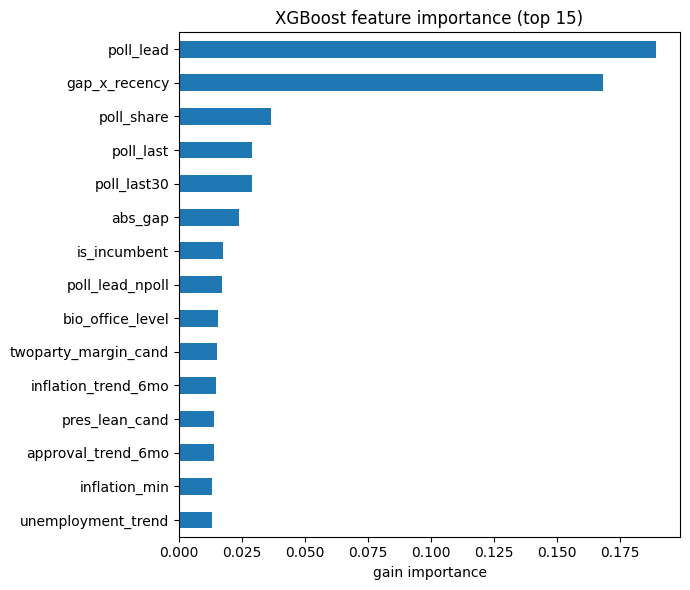

poll_lead               0.1895
gap_x_recency           0.1682
poll_share              0.0365
poll_last               0.0291
poll_last30             0.0288
abs_gap                 0.0240
is_incumbent            0.0176
poll_lead_npoll         0.0171
bio_office_level        0.0155
twoparty_margin_cand    0.0152
inflation_trend_6mo     0.0148
pres_lean_cand          0.0138
approval_trend_6mo      0.0137
inflation_min           0.0131
unemployment_trend      0.0129
dtype: float32

In [13]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

# Full importance table -> CSV (all features, ranked)
imp_df = imp.rename('gain_importance').reset_index().rename(columns={'index': 'feature'})
imp_df['rank'] = range(1, len(imp_df) + 1)
imp_df.to_csv('models/poll/feature_importance.csv', index=False)  # beside the model (2026-08-02)
print('wrote models/poll/feature_importance.csv  (', len(imp_df), 'features )')

# Chart: top 15 only
top15 = imp.head(15).sort_values()
ax = top15.plot.barh(figsize=(7, 6), title='XGBoost feature importance (top 15)')
ax.set_xlabel('gain importance')
plt.tight_layout(); plt.show()

imp.head(15).round(4)

### SHAP — top 15 features

Gain importance (above) says *how much* a feature was used. SHAP says *which direction* it
pushes a prediction and *how much per candidate*. The beeswarm below shows the 15 highest-impact
features on the 2024 test set: each dot is a candidate, color = the feature's value (red high,
blue low), x-position = push toward winning (right) or losing (left).

top 15 by mean |SHAP|: ['poll_lead', 'gap_x_recency', 'poll_last', 'pres_lean_cand', 'poll_share', 'bio_office_level', 'fund_cash_share', 'poll_lead_npoll', 'poll_last30', 'is_incumbent', 'abs_gap', 'twoparty_margin_cand', 'midterm_approval_cand', 'fund_pac_pct', 'fund_spend_share']


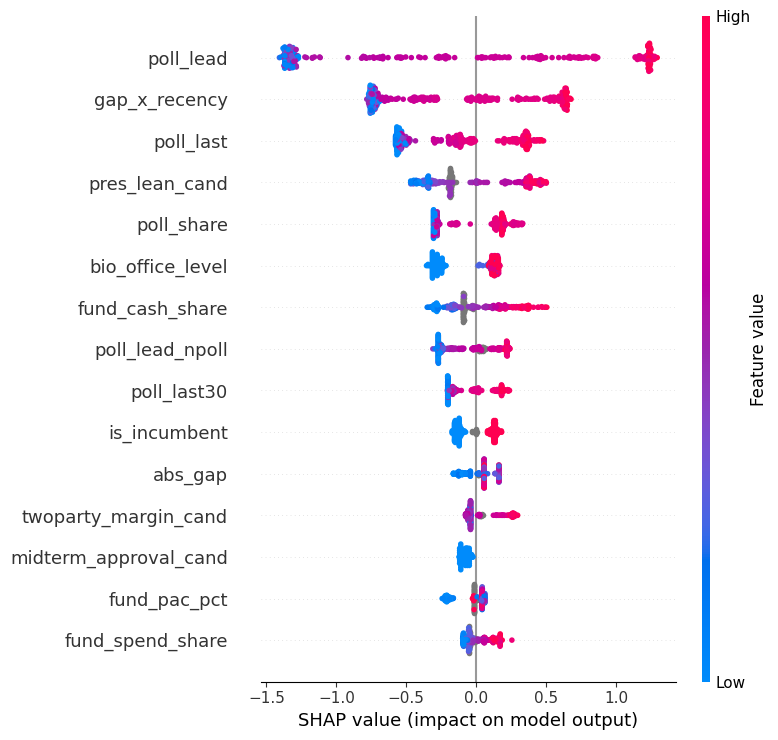

In [14]:
import shap

# SHAP values for the trained model on the test set (TreeExplainer = exact + fast for XGBoost)
explainer = shap.TreeExplainer(model)
shap_exp = explainer(X_test)

# rank features by mean |SHAP| and keep the top 15
mean_abs = np.abs(shap_exp.values).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:15]
top_features = [FEATURES[i] for i in order]
print('top 15 by mean |SHAP|:', top_features)

# beeswarm of just those 15 — show=False so the figure is captured (esp. in headless/nbconvert)
plt.figure()
shap.summary_plot(shap_exp.values[:, order], X_test.iloc[:, order],
                  feature_names=top_features, max_display=15, show=False)
plt.tight_layout(); plt.show()

## 9. Calibration curve

Are predicted probabilities honest? A well-calibrated model: candidates given ~70% win ~70% of the time.

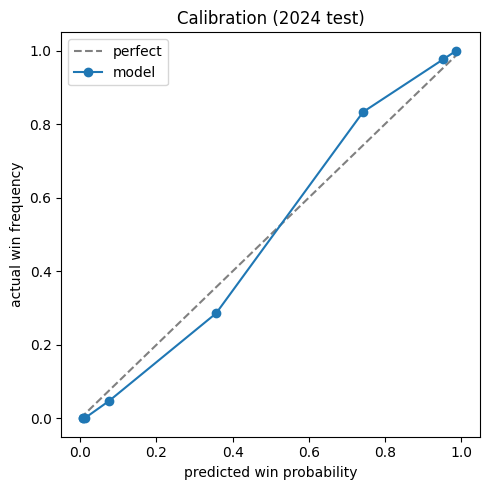

In [15]:
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8, strategy='quantile')
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], '--', color='gray', label='perfect')
plt.plot(mean_pred, frac_pos, 'o-', label='model')
plt.xlabel('predicted win probability'); plt.ylabel('actual win frequency')
plt.title('Calibration (2024 test)'); plt.legend(); plt.tight_layout(); plt.show()

## 10. Honest evaluation: leave-one-cycle-out on 2018–2024

Each fold trains on the other 13 cycles and tests the held-out modern cycle. Because hyperparameters were selected on 1998–2016 only, these numbers carry **no selection bias**. The pollster house-effect (`poll_adj`) is recomputed from each fold's training cycles only (leak-free).

In [16]:
# KS statistic: max gap between winner/loser predicted-prob CDFs = max(TPR-FPR).
def _ks(y, p):
    fpr, tpr, _ = roc_curve(y, p)
    return float((tpr - fpr).max())

def make_model():
    return xgb.XGBClassifier(**XGB_PARAMS)   # tuned on 1998-2016 only (section 5)

# COMPANION eval: leave-one-cycle-out over 2018-2024. Each fold trains on the other 13
# cycles INCLUDING FUTURE ones (test 2018 -> trains on 2020-2024) - impossible in
# deployment, so this is kept only to monitor the optimism gap vs the PRIMARY
# expanding-window eval in the next cell (gap measured ~0.000-0.003, 2026-07-14).
cv_rows = []
for test_y in EVAL_CYCLES:
    c = FOLDS[test_y]
    tr = c[c['year'] != test_y]; te = c[c['year'] == test_y].copy()
    m = make_model(); m.fit(tr[FEATURES], tr['won'].astype(int))
    te['p'] = m.predict_proba(te[FEATURES])[:, 1]
    pick = te.loc[te.groupby('race_id')['p'].idxmax()]
    base = te.loc[te.groupby('race_id')['poll_avg'].idxmax()]
    cv_rows.append(dict(
        test_cycle=test_y, n_cand=len(te), n_races=te['race_id'].nunique(),
        AUC=roc_auc_score(te['won'].astype(int), te['p']),
        AUC_PR=average_precision_score(te['won'].astype(int), te['p']),  # avg precision (win class)
        KS=_ks(te['won'].astype(int), te['p']),  # max separation winners vs losers
        Brier=brier_score_loss(te['won'].astype(int), te['p']),
        LogLoss=log_loss(te['won'].astype(int), te['p']),
        race_acc=pick['won'].mean(), baseline_acc=base['won'].mean(),
    ))

cv = pd.DataFrame(cv_rows).set_index('test_cycle')
print('=== companion eval: LOCO on 2018-2024 (trains on future cycles; headline is the expanding-window table below) ===')
print(cv.round(3).to_string())
print('\nMEAN over eval cycles:')
print(cv[['AUC', 'AUC_PR', 'KS', 'Brier', 'LogLoss', 'race_acc', 'baseline_acc']].mean().round(3).to_string())

=== companion eval: LOCO on 2018-2024 (trains on future cycles; headline is the expanding-window table below) ===
            n_cand  n_races    AUC  AUC_PR     KS  Brier  LogLoss  race_acc  baseline_acc
test_cycle                                                                               
2018           641      229  0.977   0.960  0.844  0.058    0.190     0.882         0.882
2020           413      150  0.960   0.933  0.783  0.080    0.243     0.827         0.833
2022           472      174  0.974   0.958  0.828  0.065    0.202     0.879         0.885
2024           338      133  0.981   0.970  0.859  0.054    0.181     0.917         0.880

MEAN over eval cycles:
AUC             0.973
AUC_PR          0.955
KS              0.829
Brier           0.064
LogLoss         0.204
race_acc        0.876
baseline_acc    0.870


In [17]:
# PRIMARY HONEST EVAL - EXPANDING-WINDOW: train strictly on cycles BEFORE the test
# cycle, exactly what a real forecaster could have done (2018 trains on 1998-2016, ...,
# 2024 on 1998-2022). Tuner (1998-2016 only) never saw these cycles. These are THE
# headline numbers. The LOCO-minus-expanding gap below monitors how optimistic the
# companion LOCO scheme above is (~zero when measured 2026-07-14).
ew_rows = []
for test_y in EVAL_CYCLES:
    c = FOLDS[test_y]
    tr = c[c['year'] < test_y]; te = c[c['year'] == test_y].copy()
    m = make_model(); m.fit(tr[FEATURES], tr['won'].astype(int))
    te['p'] = m.predict_proba(te[FEATURES])[:, 1]
    pick = te.loc[te.groupby('race_id')['p'].idxmax()]
    ew_rows.append(dict(
        test_cycle=test_y, n_train_cycles=tr['year'].nunique(),
        AUC=roc_auc_score(te['won'].astype(int), te['p']),
        AUC_PR=average_precision_score(te['won'].astype(int), te['p']),
        KS=_ks(te['won'].astype(int), te['p']),
        Brier=brier_score_loss(te['won'].astype(int), te['p']),
        race_acc=pick['won'].mean(),
    ))
ew = pd.DataFrame(ew_rows).set_index('test_cycle')
print('=== PRIMARY honest eval: EXPANDING-WINDOW on 2018-2024 (train < test cycle; true prospective) ===')
print(ew.round(3).to_string())
print()
print('MEAN over eval cycles:')
print(ew[['AUC', 'AUC_PR', 'KS', 'Brier', 'race_acc']].mean().round(3).to_string())
print()
print('LOCO-minus-expanding gaps (positive = LOCO optimistic):')
for k in ['AUC', 'AUC_PR', 'KS', 'race_acc']:
    print(f'  {k:8} {cv[k].mean() - ew[k].mean():+.4f}')
print(f'  {"Brier":8} {cv["Brier"].mean() - ew["Brier"].mean():+.4f} (negative = LOCO optimistic)')


=== PRIMARY honest eval: EXPANDING-WINDOW on 2018-2024 (train < test cycle; true prospective) ===
            n_train_cycles    AUC  AUC_PR     KS  Brier  race_acc
test_cycle                                                       
2018                    10  0.979   0.964  0.857  0.055     0.900
2020                    11  0.959   0.931  0.787  0.081     0.820
2022                    12  0.974   0.957  0.830  0.064     0.874
2024                    13  0.981   0.970  0.859  0.054     0.917

MEAN over eval cycles:
AUC         0.973
AUC_PR      0.956
KS          0.833
Brier       0.064
race_acc    0.878

LOCO-minus-expanding gaps (positive = LOCO optimistic):
  AUC      -0.0001
  AUC_PR   -0.0006
  KS       -0.0047
  race_acc -0.0013
  Brier    +0.0004 (negative = LOCO optimistic)


## 11. Honest benchmark: does the model beat a pure poll signal?

The single biggest question for a project like this: **does the ML model actually beat just using the polls?** Here we build a trivial baseline — convert each candidate's weighted poll average into a win probability via a softmax within the race — and compare it to the XGBoost model under the same leave-one-cycle-out CV.

We also sweep a **blend** `α·model + (1−α)·poll` to see whether mixing helps (α=1 is pure model, α=0 is pure poll).

In [18]:
# tune the BASELINE's temperature on the tune cycles first — an under-tuned baseline
# would flatter the model in the comparison below
def poll_softmax(g, temp=3.0):
    """Turn raw poll averages into within-race win probabilities (smooth 'leader' signal)."""
    v = g['poll_avg'].fillna(g['poll_avg'].mean()).values
    e = np.exp((v - np.nanmax(v)) / temp)
    return pd.Series(e / e.sum(), index=g.index)

def race_winner_acc(te, col):
    pick = te.loc[te.groupby('race_id')[col].idxmax()]
    return pick['won'].mean()

def _base_brier(temp, cycles):
    bs = []
    for ty in cycles:
        te = FOLDS[ty][FOLDS[ty]['year'] == ty]
        pp = te.groupby('race_id', group_keys=False).apply(lambda g: poll_softmax(g, temp))
        bs.append(brier_score_loss(te['won'].astype(int), pp))
    return float(np.mean(bs))
BASE_TEMP = min([1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0], key=lambda t: _base_brier(t, TUNE_CYCLES))
print('baseline softmax temperature (tuned on 1998-2016):', BASE_TEMP)

# per-fold predictions on the honest eval cycles (model prob + poll prob),
# EXPANDING-WINDOW (train strictly before the test cycle - matches the primary eval)
fold_pred = {}
for test_y in EVAL_CYCLES:
    c = FOLDS[test_y]
    tr = c[c['year'] < test_y]
    te = c[c['year'] == test_y].copy()
    m = make_model(); m.fit(tr[FEATURES], tr['won'].astype(int))
    te['p_model'] = m.predict_proba(te[FEATURES])[:, 1]
    te['p_poll']  = te.groupby('race_id', group_keys=False).apply(lambda g: poll_softmax(g, BASE_TEMP))
    fold_pred[test_y] = te

def cv_metrics(col):
    y = lambda ty: fold_pred[ty]['won'].astype(int)
    a  = np.mean([roc_auc_score(y(ty), fold_pred[ty][col]) for ty in EVAL_CYCLES])
    pr = np.mean([average_precision_score(y(ty), fold_pred[ty][col]) for ty in EVAL_CYCLES])
    ks = np.mean([_ks(y(ty), fold_pred[ty][col]) for ty in EVAL_CYCLES])
    b  = np.mean([brier_score_loss(y(ty), fold_pred[ty][col]) for ty in EVAL_CYCLES])
    r  = np.mean([race_winner_acc(fold_pred[ty], col) for ty in EVAL_CYCLES])
    return a, pr, ks, b, r

am, prm, ksm, bm, rm = cv_metrics('p_model')
ap, prp, ksp, bp, rp = cv_metrics('p_poll')
print('=== Honest eval 2018-2024, expanding-window: XGBoost model vs pure poll signal ===')
print(f'  XGBoost model : AUC {am:.3f}  AUC-PR {prm:.3f}  KS {ksm:.3f}  Brier {bm:.3f}  race-acc {rm:.3f}')
print(f'  poll softmax  : AUC {ap:.3f}  AUC-PR {prp:.3f}  KS {ksp:.3f}  Brier {bp:.3f}  race-acc {rp:.3f}')

print('\n=== Blend sweep  (alpha=1 pure model, 0 pure poll) ===')
print('alpha   AUC    Brier  race-acc')
for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    aucs, briers, accs = [], [], []
    for ty in EVAL_CYCLES:
        te = fold_pred[ty]
        blend = a * te['p_model'] + (1 - a) * te['p_poll']
        aucs.append(roc_auc_score(te['won'].astype(int), blend))
        briers.append(brier_score_loss(te['won'].astype(int), blend))
        pick = te.loc[blend.groupby(te['race_id']).idxmax()]
        accs.append(pick['won'].mean())
    print(f'{a:.2f}   {np.mean(aucs):.3f}  {np.mean(briers):.3f}  {np.mean(accs):.3f}')

baseline softmax temperature (tuned on 1998-2016): 4.0


=== Honest eval 2018-2024, expanding-window: XGBoost model vs pure poll signal ===
  XGBoost model : AUC 0.973  AUC-PR 0.956  KS 0.833  Brier 0.064  race-acc 0.878
  poll softmax  : AUC 0.969  AUC-PR 0.949  KS 0.817  Brier 0.071  race-acc 0.870

=== Blend sweep  (alpha=1 pure model, 0 pure poll) ===
alpha   AUC    Brier  race-acc
0.00   0.969  0.071  0.870
0.25   0.972  0.067  0.868
0.50   0.973  0.065  0.874
0.75   0.974  0.064  0.878
1.00   0.973  0.064  0.878


In [19]:
# ---- PRODUCTION artifact: train on ALL 14 cycles, save for predict.py ----
import json

prod = xgb.XGBClassifier(**XGB_PARAMS)
prod.fit(BASE[FEATURES], BASE['won'].astype(int))
prod.save_model('data/model_xgb.json')
with open('data/model_features.json', 'w') as f:
    json.dump({'features': FEATURES, 'macro_feats': MACRO_FEATS,
               'trained_on_cycles': sorted(BASE['year'].unique().tolist()),
               'xgb_params': {k: v for k, v in XGB_PARAMS.items()
                              if k not in ('eval_metric',)}}, f, indent=1)
print('saved data/model_xgb.json + data/model_features.json',
      f'({len(FEATURES)} features, {BASE["race_id"].nunique()} races)')

saved data/model_xgb.json + data/model_features.json (207 features, 1985 races)


## Notes / what's in here

**Feature families (all leak-free):** polls (weighted avg, last-30d, n_polls, polls-over-50%, std); race-relative gap (`poll_lead`, `twoparty_margin_cand`, `abs_gap`, `gap_x_recency` — a top feature); lead dynamics over time (`avg_margin_over_time` — top-4; `min_margin`; trend/volatility/lead-changes); fundamentals (`lean_cand`, `prior_margin_cand`, `is_incumbent`); environment/quality (`natl_env_cand`, `poll_momentum`, `poll_wavg_adj`).

**Hyperparameters** are CV-tuned (section 10): `max_depth=2, lr=0.03, n_estimators=200`.

**Cross-validated performance (leave-one-cycle-out):** AUC ≈ 0.96, Brier ≈ 0.08, race-winner accuracy ≈ 0.85.

### The headline honest finding (section 11)
**A trivial poll-only baseline beats this model.** Converting the weighted poll average into a within-race probability (softmax) scores AUC ≈ 0.965 / Brier ≈ 0.071 / race-acc ≈ 0.872 — better than the 38-feature XGBoost (≈0.959 / 0.080 / 0.846) on *every* CV metric. A blend `α·model + (1−α)·poll` is best at **α ≈ 0** (pure poll). 

Interpretation: for U.S. Senate/House/Governor **win-or-lose** prediction, the late polling average is so dominant that engineered features and gradient boosting add essentially nothing — and slightly hurt, by occasionally overriding a correct narrow poll leader. This is a real, well-known property of these races, not a bug in the pipeline. The model is still a perfectly good, well-calibrated probability model; it just isn't *better than the polls it's built on*.

### Where a model could actually add value (next steps)
- **Predict margin / overperformance vs polls**, not win/lose — a harder target where features have room to help.
- **House-specific model** with a time-varying district PVI (the one place polls are thin).
- **Probability calibration** (isotonic/Platt) if you only care about Brier.
- **Don't** add `vote_pct` / `race_winning_pct` — they're the answer.